In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import joblib
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

project_root = '/Users/namansoni/Project/macro-regime-classifier'

df = pd.read_csv(os.path.join(project_root, 'data', 'macro_features_clean.csv'), index_col = 0, parse_dates = True)

print(df.head())
print(df.shape)

                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2000-01-31  0.037212           0.1    1.500000         0.07           1.68   
2000-02-29  0.037212           0.1    3.500000        -0.11           1.91   
2000-03-31  0.037212          -0.1    5.500000        -0.47           2.30   
2000-04-30  0.037212          -0.2    7.500000        -0.45           2.34   
2000-05-31  0.037212           0.2    5.133333        -0.40           2.52   

            consumer_sent  indust_prod  
2000-01-31           -0.7       0.2859  
2000-02-29           -0.7       0.2859  
2000-03-31           -4.2       0.3265  
2000-04-30            2.1       0.5485  
2000-05-31            1.5       0.2510  
(319, 7)


In [2]:
scaler = StandardScaler()

arrays = scaler.fit_transform(df)

In [3]:
scaled_df = pd.DataFrame(arrays, index = df.index, columns = df.columns)
print(scaled_df)

                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2000-01-31  0.640496      0.155636   -0.195286    -1.013349      -1.040280   
2000-02-29  0.640496      0.155636    0.311805    -1.200402      -0.730556   
2000-03-31  0.640496     -0.158591    0.818897    -1.574508      -0.205371   
2000-04-30  0.640496     -0.315705    1.325988    -1.553724      -0.151506   
2000-05-31  0.640496      0.312750    0.725930    -1.501765       0.090887   
...              ...           ...         ...          ...            ...   
2026-03-31  0.387904     -0.158591   -0.043158    -0.556109      -0.892151   
2026-04-30  0.674180     -0.001478   -0.043158    -0.545717      -1.013347   
2026-05-31  0.898987     -0.001478   -0.043158    -0.597676      -1.188409   
2026-06-30  0.898987     -0.158591   -0.043158    -0.774337      -1.242274   
2026-07-31  0.898987     -0.158591   -0.043158    -0.722378      -1.201875   

            consumer_sent  indust_prod  
2000-01-31      -0.106

In [4]:
print(scaled_df.mean())
print(scaled_df.std())
#Since each column in std is off by the same amount, its clear that pandas is using the sample calculation for std, while sklearn uses the population calculation causing a small but recurring difference. 

cpi              5.011665e-17
unemployment    -1.113703e-17
gdp_growth       1.670555e-17
yield_curve      4.454813e-17
credit_spread    4.232073e-16
consumer_sent    6.960646e-18
indust_prod      1.948981e-17
dtype: float64
cpi              1.001571
unemployment     1.001571
gdp_growth       1.001571
yield_curve      1.001571
credit_spread    1.001571
consumer_sent    1.001571
indust_prod      1.001571
dtype: float64


In [5]:
src_folder = os.path.join(project_root, 'src')

os.makedirs(src_folder, exist_ok = True)

joblib.dump(scaler, os.path.join(project_root, src_folder, 'scaler.pkl'))

['/Users/namansoni/Project/macro-regime-classifier/src/scaler.pkl']

In [6]:
loaded_scaler = joblib.load(os.path.join(src_folder, 'scaler.pkl'))
print(loaded_scaler.mean_)

[ 2.61755399e-02  9.40438871e-04  2.27021944e+00  1.04514107e+00
  2.45250784e+00 -2.44200627e-01  3.65905956e-02]


In [7]:
# Day 2 -> Computing BIC scores for each of the K values from 1-7 for each sector, and determining which K value is optimal. 

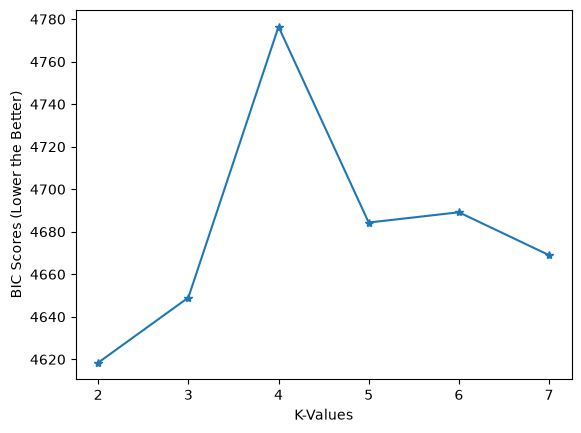

[4618.413548804312, 4649.03871483703, 4776.451506296775, 4684.334829205209, 4689.159939893181, 4668.9969027213665]


In [13]:
bic_scores = []

for i in range(2, 8):
    mixture = GaussianMixture(i, n_init = 10, random_state = 42)
    mixture.fit(scaled_df)
    bic_scores.append(mixture.bic(scaled_df))
    
k_values = list(range(2,8))
plt.plot(k_values, bic_scores, marker = '*')
plt.xlabel('K-Values')
plt.ylabel('BIC Scores (Lower the Better)')
plt.savefig(os.path.join(project_root, 'outputs', 'bic_curve.png'), dpi = 150, bbox_inches = 'tight')
plt.show()
print(bic_scores)

I fit the scaled data with the gaussian mixture model over the range of k values from 2-7, and stored their BIC into a list. The minimum BIC value was at k = 2, followed by k = 3 and k = 7. The k value that is rejected is k = 4 since it has the maximum BIC value (lower the BIC score, the better). The difference between the top options were: k = 2 -> 4618, k = 3 -> 4649, and k = 7 -> 4668. k=7 was also rejected despite being a lower value since it is beat by k = 2 and k =3 by over 20 points. k=4 had a BIC of 4776 which is over 100 points above k=2 and k = 3. I chose k = 3 as my final option since, despite k=2 having the lowest BIC, for the backtesting model, only 2 clusters would give it very little to work with, while k=3 would give it a middle cluster that'll allow it to identify a transition period of the economy rather than only risk-on/risk-off, while maintaining a lower BIC. I will also be checking by running the model over k=2 to ensure the two don't return highly varied results. 